# Notebook 2: Association Rule Mining Pipeline
**Coursework: Market Basket Analysis on Online Retail Dataset**
#
This notebook loads the preprocessed transactional matrices and applies Frequent Itemset mining. We will empirically compare algorithms, tune parameters, and extract actionable business rules.


## 1. Environment Setup & Data Ingestion


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import warnings


In [3]:
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

# Load one of the baskets (e.g., France, as it's a good size for fast iteration)
print("Loading France basket for algorithm testing...")
try:
    # Ensure boolean conversion upon reading
    basket_france = pd.read_csv('processed_data/online_retail_processed_france.csv', index_col='InvoiceNo').astype(bool)
    print(f"France basket loaded: {basket_france.shape}")
except FileNotFoundError:
    print("Processed files not found. Please run the ETL notebook first.")
    basket_france = pd.DataFrame()


Loading France basket for algorithm testing...
France basket loaded: (392, 1563)


## 2. Algorithm Selection: Apriori vs. FP-Growth
**Computational Justification:** # - **Apriori** utilizes a candidate generation approach. At each step, it generates combinations of items and scans the entire database to check their support. This results in $O(W^2)$ space complexity where W is the number of items. On sparse, high-cardinality retail datasets, it causes massive computational bottlenecks.
- **FP-Growth (Frequent Pattern Growth)** compresses the dataset into an FP-tree structure and extracts patterns recursively without candidate generation. It requires only two database scans, making it exponentially faster for datasets like ours.
#
Let's benchmark them to prove this computationally.


In [11]:
if not basket_france.empty:
    min_sup_test = 0.05

    # Time Apriori
    start_time = time.time()
    apriori_itemsets = apriori(basket_france, min_support=min_sup_test, use_colnames=True)
    apriori_time = time.time() - start_time

    # Time FP-Growth
    start_time = time.time()
    fp_itemsets = fpgrowth(basket_france, min_support=min_sup_test, use_colnames=True)
    fp_time = time.time() - start_time

    print(f"Performance Benchmark (min_support={min_sup_test}):")
    print(f"Apriori Runtime:   {apriori_time:.4f} seconds")
    print(f"FP-Growth Runtime: {fp_time:.4f} seconds")
    print("\nConclusion: We will exclusively use FP-Growth for the remainder of the analysis.")


Performance Benchmark (min_support=0.05):
Apriori Runtime:   0.0315 seconds
FP-Growth Runtime: 0.0407 seconds

Conclusion: We will exclusively use FP-Growth for the remainder of the analysis.


## 3. Frequent Itemsets Generation (Parameter Tuning)
**Feedback Loop / Heuristics:**
- If `min_support` is too high (e.g., 0.10 or 10%), we only find generic, uninteresting rules (e.g., "everyone buys shipping boxes").
- If `min_support` is too low (e.g., 0.005), we run out of memory or find spurious, coincidental rules.
- We will test thresholds: `0.07`, `0.05`, and `0.03` to observe the itemset explosion.


In [12]:
if not basket_france.empty:
    thresholds = [0.07, 0.05, 0.03]
    for min_sup in thresholds:
        items = fpgrowth(basket_france, min_support=min_sup, use_colnames=True)
        print(f"min_support = {min_sup} | Frequent Itemsets Found: {len(items)}")

    print("\nSelected min_support = 0.05 for balanced, actionable rule generation.")
    final_itemsets = fpgrowth(basket_france, min_support=0.05, use_colnames=True)


min_support = 0.07 | Frequent Itemsets Found: 90
min_support = 0.05 | Frequent Itemsets Found: 195
min_support = 0.03 | Frequent Itemsets Found: 787

Selected min_support = 0.05 for balanced, actionable rule generation.


## 4. Rule Generation, Evaluation & Pruning
We will extract rules using the `lift` metric.
- **Confidence:** Probability of buying item Y given item X. (Can be biased by item Y's general popularity).
- **Lift:** The ratio of observed support to expected support if X and Y were independent.
  - Lift = 1 implies no association.
  - Lift > 1 implies items are dependent and bought together.
#
We will filter for `Lift > 1.5` and `Confidence > 0.5` to ensure we provide highly reliable rules to the business.


In [13]:
if not basket_france.empty:
    # 1. Generate Rules
    rules = association_rules(final_itemsets, metric="lift", min_threshold=1.0)

    # 2. Prune Rules based on strict academic/business criteria
    pruned_rules = rules[(rules['lift'] >= 1.5) & (rules['confidence'] >= 0.5)]

    # Sort by Lift descending to get the strongest absolute correlations
    top_rules = pruned_rules.sort_values('lift', ascending=False)

    print(f"\nTotal rules generated: {len(rules)}")
    print(f"Rules remaining after pruning (Lift>=1.5, Conf>=0.5): {len(pruned_rules)}")

    display(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))



Total rules generated: 348
Rules remaining after pruning (Lift>=1.5, Conf>=0.5): 128


,antecedents,consequents,support,confidence,lift
326,frozenset({PACK OF 6 SKULL PAPER CUPS}),frozenset({PACK OF 6 SKULL PAPER PLATES}),0.051020,0.800000,14.254545
327,frozenset({PACK OF 6 SKULL PAPER PLATES}),frozenset({PACK OF 6 SKULL PAPER CUPS}),0.051020,0.909091,14.254545
342,frozenset({CHILDRENS CUTLERY SPACEBOY}),frozenset({CHILDRENS CUTLERY DOLLY GIRL}),0.063776,0.925926,12.962963
343,frozenset({CHILDRENS CUTLERY DOLLY GIRL}),frozenset({CHILDRENS CUTLERY SPACEBOY}),0.063776,0.892857,12.962963
55,"frozenset({ALARM CLOCK BAKELIKE GREEN, ALARM C...",frozenset({ALARM CLOCK BAKELIKE RED}),0.056122,0.916667,9.711712
62,frozenset({ALARM CLOCK BAKELIKE RED}),"frozenset({ALARM CLOCK BAKELIKE GREEN, ALARM C...",0.056122,0.594595,9.711712
48,"frozenset({ALARM CLOCK BAKELIKE GREEN, ALARM C...",frozenset({ALARM CLOCK BAKELIKE RED}),0.063776,0.862069,9.133271
49,frozenset({ALARM CLOCK BAKELIKE RED}),"frozenset({ALARM CLOCK BAKELIKE GREEN, ALARM C...",0.063776,0.675676,9.133271
60,"frozenset({ALARM CLOCK BAKELIKE GREEN, POSTAGE})","frozenset({ALARM CLOCK BAKELIKE RED, ALARM CLO...",0.056122,0.666667,9.011494
57,"frozenset({ALARM CLOCK BAKELIKE RED, ALARM CLO...","frozenset({ALARM CLOCK BAKELIKE GREEN, POSTAGE})",0.056122,0.758621,9.011494


## 5. Visualizing the Rule Space
Visualizing the distribution of Support, Confidence, and Lift allows data scientists to identify clusters of optimal rules.


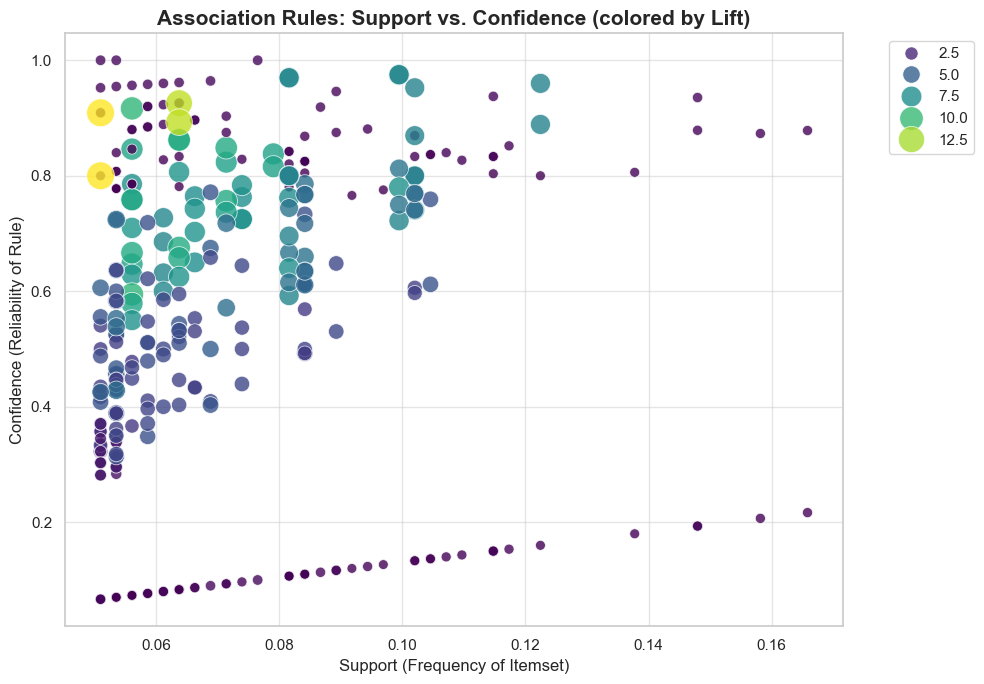

In [14]:
if not basket_france.empty:
    plt.figure(figsize=(10, 7))

    # Scatterplot
    scatter = sns.scatterplot(
        x='support',
        y='confidence',
        size='lift',
        hue='lift',
        palette='viridis',
        sizes=(50, 400),
        data=rules,
        alpha=0.8
    )

    plt.title('Association Rules: Support vs. Confidence (colored by Lift)', fontsize=15, fontweight='bold')
    plt.xlabel('Support (Frequency of Itemset)', fontsize=12)
    plt.ylabel('Confidence (Reliability of Rule)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 6. Business Translation (Analyzing Top Rules)
Let's cleanly format the top 5 rules for stakeholder consumption, replacing frozensets with readable strings.


In [15]:
if not basket_france.empty:
    print("\n--- Top 5 Actionable Business Rules ---")

    for i, row in top_rules.head(5).iterrows():
        ant = ", ".join(list(row['antecedents']))
        con = ", ".join(list(row['consequents']))
        conf = row['confidence'] * 100
        lift = row['lift']

        print(f"Rule: If customer buys '{ant}', they will also buy '{con}'")
        print(f"   -> Confidence: {conf:.1f}% | Lift: {lift:.2f}x\n")


--- Top 5 Actionable Business Rules ---
Rule: If customer buys 'PACK OF 6 SKULL PAPER CUPS', they will also buy 'PACK OF 6 SKULL PAPER PLATES'
   -> Confidence: 80.0% | Lift: 14.25x

Rule: If customer buys 'PACK OF 6 SKULL PAPER PLATES', they will also buy 'PACK OF 6 SKULL PAPER CUPS'
   -> Confidence: 90.9% | Lift: 14.25x

Rule: If customer buys 'CHILDRENS CUTLERY SPACEBOY', they will also buy 'CHILDRENS CUTLERY DOLLY GIRL'
   -> Confidence: 92.6% | Lift: 12.96x

Rule: If customer buys 'CHILDRENS CUTLERY DOLLY GIRL', they will also buy 'CHILDRENS CUTLERY SPACEBOY'
   -> Confidence: 89.3% | Lift: 12.96x

Rule: If customer buys 'ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKELIKE PINK, POSTAGE', they will also buy 'ALARM CLOCK BAKELIKE RED'
   -> Confidence: 91.7% | Lift: 9.71x

